# Isomap: Isometric Mapping

## What is Isomap?

**Isomap** is a nonlinear dimensionality reduction technique that combines ideas from both MDS and LLE. Like MDS, it works by preserving pairwise distances between points in a low-dimensional embedding. But unlike standard MDS (which uses straight-line Euclidean distance), Isomap first estimates **geodesic distance** — the distance measured *along the curved surface* of the data — and preserves *that* instead.

This is the fix for the exact weakness flagged earlier with MDS on the Swiss roll: two points on adjacent rolls of the spiral can be close in straight-line 3D distance while being far apart if you had to walk along the actual rolled surface to get from one to the other. Isomap avoids being fooled by this, by estimating distances through a **neighborhood graph** (similar to LLE's first step) rather than jumping straight to raw Euclidean distance between any two points.

## Steps to Compute Isomap

1. **Find the k nearest neighbors** of every data point (identical to LLE's first step) — using a standard distance metric in the original high-dimensional space.

2. **Construct the neighborhood graph**: connect each point to its k nearest neighbors (with edge weights equal to their distance), leaving points that aren't neighbors unconnected. This graph approximates the *local* structure of the manifold — trustworthy only over short distances.

3. **Compute the shortest path between every pair of points** through this graph (typically via Dijkstra's algorithm). This shortest-path distance — hopping neighbor to neighbor across the graph — approximates the true **geodesic distance** along the manifold's surface, even between points that are far apart. This is the key idea: geodesic distance is built up from many trustworthy *local* hops, rather than one untrustworthy *global* straight line.

4. **Run MDS on the resulting geodesic distance matrix**: with all pairwise geodesic distances now known, feed them into standard MDS to find low-dimensional coordinates whose Euclidean distances match these geodesic distances as closely as possible (minimizing the same stress formula seen earlier).

## Comparison: Isomap vs. PCA vs. MDS vs. LLE

| | PCA | MDS | LLE | Isomap |
|---|---|---|---|---|
| Structure preserved | Global variance (linear directions) | All pairwise distances (straight-line, global) | Local neighborhood relationships only | Global pairwise **geodesic** distances |
| Linear or nonlinear | Linear | Linear (classical) | Nonlinear | Nonlinear |
| Works on | Feature covariance matrix | Distance matrix (straight-line) | k-NN graph + local reconstruction weights | k-NN graph + shortest-path (geodesic) distances, then MDS |
| Solution method | Eigen-decomposition (closed-form) | Iterative stress-minimization | Two-stage: local weights, then eigen-decomposition | Three-stage: neighbor graph, shortest paths, then MDS |
| Handles curved manifolds well? | No | Partially — distorted by straight-line vs. along-surface mismatch | Yes — via purely local geometry | Yes — via geodesic distance, preserving *global* layout too |
| Key hyperparameter | Number of components | Number of components | Number of neighbors (k) | Number of neighbors (k) |

**Where Isomap sits relative to the others:** LLE only ever looks at small local neighborhoods and never tries to preserve how far apart two distant points *really* are along the manifold — it can unroll the shape well, but distances between far-apart regions in the embedding aren't especially meaningful. Isomap, by chaining together local neighbor-hops into full geodesic distances, aims to preserve *both* the local structure (like LLE) *and* a meaningful global layout (like MDS) — at the cost of being more sensitive to neighbor-graph errors: if the k-NN graph ever "short-circuits" (as flagged earlier, e.g. via the added flat sheet sitting close to the roll), the estimated geodesic distances can become badly wrong, since a single bad shortcut in the graph can throw off many shortest-path calculations at once.

In [1]:
# Data manipulation
import numpy as np

# Visualization
import plotly.express as px

# Skleran
from sklearn.datasets import make_swiss_roll # for creating swiss roll
from sklearn.manifold import Isomap # for Isomap dimensionality reduction

In [2]:
# Create a swiss roll
X, y = make_swiss_roll(n_samples=2000, noise=0.05)

# Make it thinner
X[:, 1] *= .5

# Create a flat addon to the top of the swiss roll
X_x=np.zeros((300,1))
X_y=np.random.uniform(low=0, high=10, size=(300,1))
X_z=np.random.uniform(low=14, high=25, size=(300,1))
X2=np.concatenate((X_x, X_y, X_z), axis=1)
y2=X_z.reshape(300)

# Concatenate swiss roll and flat rectangle arrays
X_two=np.concatenate((X, X2))
y_two=np.concatenate((y, y2))

In [3]:
# Create a 3D scatter plot
def Plot3D(X, y, plot_name):
    fig = px.scatter_3d(None,
                        x=X[:,0], y=X[:,1], z=X[:,2],
                        color=y,
                        height=800, width=800
                       )
    # Update chart looks
    fig.update_layout(title_text=plot_name,
                      showlegend=False,
                      legend=dict(orientation="h", yanchor="top", y=0, xanchor="center", x=0.5),
                      scene_camera=dict(up=dict(x=0, y=0, z=1),
                                            center=dict(x=0, y=0, z=-0.1),
                                            eye=dict(x=1.5, y=1.75, z=1)),
                                            margin=dict(l=0, r=0, b=0, t=0),
                      scene = dict(xaxis=dict(backgroundcolor='white',
                                              color='black',
                                              gridcolor='#f0f0f0',
                                              title_font=dict(size=10),
                                              tickfont=dict(size=10),
                                             ),
                                   yaxis=dict(backgroundcolor='white',
                                              color='black',
                                              gridcolor='#f0f0f0',
                                              title_font=dict(size=10),
                                              tickfont=dict(size=10),
                                              ),
                                   zaxis=dict(backgroundcolor='lightgrey',
                                              color='black',
                                              gridcolor='#f0f0f0',
                                              title_font=dict(size=10),
                                              tickfont=dict(size=10),
                                             )))
    # Update marker size
    fig.update_traces(marker=dict(size=3,
                                  line=dict(color='black', width=0.1)))
    fig.update(layout_coloraxis_showscale=False)
    return fig


#----------------------------------------------
# Create a 2D scatter plot
def Plot2D(X, y, plot_name):
    # Create a scatter plot
    fig = px.scatter(None, x=X[:,0], y=X[:,1],
                     labels={
                         "x": "Dimension 1",
                         "y": "Dimension 2",
                     },
                     opacity=1, color=y)

    # Change chart background color
    fig.update_layout(dict(plot_bgcolor = 'white'))

    # Update axes lines
    fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='lightgrey',
                     zeroline=True, zerolinewidth=1, zerolinecolor='lightgrey',
                     showline=True, linewidth=1, linecolor='black')

    fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgrey',
                     zeroline=True, zerolinewidth=1, zerolinecolor='lightgrey',
                     showline=True, linewidth=1, linecolor='black')

    # Set figure title
    fig.update_layout(title_text=plot_name)

    # Update marker size
    fig.update_traces(marker=dict(size=5,
                                 line=dict(color='black', width=0.3)))
    return fig

In [5]:
# Function for performing Isomap
def run_isomap(num_neighbors, dims, data):
    # A reusable wrapper function around scikit-learn's Isomap,
    # mirroring the structure of run_lle from the previous notebook —
    # same pattern: configure, fit_transform, return the embedding.

    # Specify Isomap parameters
    embed_isomap = Isomap(n_neighbors=num_neighbors, n_components=dims)
    # Create an Isomap instance:
    #   - n_neighbors=num_neighbors: the "k" from step 1 of the Isomap
    #     algorithm — how many nearest neighbors each point connects to
    #     when building the neighborhood graph (step 2), which is then
    #     used to compute shortest-path geodesic distances (step 3).
    #     Same role as LLE's n_neighbors, but here it also controls how
    #     easily the graph can "short-circuit" across unrelated regions
    #     (like the flat sheet) — since Isomap chains many local hops
    #     into long-range distances, a single bad neighbor connection
    #     can corrupt many shortest-path distances at once, making
    #     Isomap generally MORE sensitive to a badly chosen k than LLE.
    #   - n_components=dims: the target dimensionality of the final
    #     embedding (produced by the internal MDS step, step 4).
    #
    # Note: unlike run_lle, there's no reg parameter here — Isomap
    # doesn't need the same ill-conditioning fix, since it isn't
    # solving the same local-reconstruction-weight problem LLE solves;
    # its neighbor graph is only used for distances, not for fitting
    # weighted linear combinations.

    # Fit and transofrm the data
    result = embed_isomap.fit_transform(data)
    # Run the full Isomap pipeline on `data`: build the k-NN graph,
    # compute all-pairs shortest-path (geodesic) distances via
    # Dijkstra's algorithm, then run MDS on that geodesic distance
    # matrix to produce the final low-dimensional coordinates.

    # Return results
    return result
    # Return just the resulting embedding, shape (n_samples, dims) —
    # same convention as run_lle, ready to be passed into Plot2D(...).

In [7]:
## Isomap on a regular swiss roll
isomap_res=run_isomap(num_neighbors=30, dims=2, data=X)
# Run Isomap on the plain Swiss roll (X, 2000 points, no flat sheet),
# with 30 neighbors, reducing to 2D. isomap_res will have shape
# (2000, 2) — the "unrolled" 2D layout for the clean roll, directly
# comparable to std_lle_res from the LLE notebook, since both use the
# same data and the same neighbor count.

######### Modified swiss roll #########

## Isomap on a modified swiss roll
mod_isomap_res=run_isomap(num_neighbors=30, dims=2, data=X_two)
# Run Isomap on the combined dataset (X_two, 2300 points — roll +
# nearby flat sheet), same 30 neighbors, 2D output. mod_isomap_res
# will have shape (2300, 2) — this is the test of whether Isomap's
# neighbor graph "short-circuits" across the two nearby surfaces, same
# scenario tested with LLE earlier (there as std_mlle_res, despite that
# variable's misleading name).

In [9]:
import plotly.io as pio
pio.renderers.default = "colab"
fig = Plot2D(isomap_res, y, 'Regular Swiss Roll - Isomap')
fig

In [10]:
import plotly.io as pio
pio.renderers.default = "colab"
fig = Plot2D(mod_isomap_res, y_two, 'Modified Swiss Roll - Isomap')
fig

In [11]:
# Visualization
import plotly.express as px
import matplotlib.pyplot as plt

# Sklearn
from sklearn.datasets import load_digits # for MNIST data
from sklearn.manifold import Isomap # for Isomap dimensionality reduction

We load the MNIST data that contains handwritten digits images with its correct label.

In [12]:
# Load digits data
digits = load_digits()

# Load arrays containing digit data (64 pixels per image) and their true labels
X, y = load_digits(return_X_y=True)

# Some stats
print('Shape of digit images: ', digits.images.shape)
print('Shape of X (training data): ', X.shape)
print('Shape of y (true labels): ', y.shape)

Shape of digit images:  (1797, 8, 8)
Shape of X (training data):  (1797, 64)
Shape of y (true labels):  (1797,)


Let’s display the first 10 handwritten digits, so we have a better idea of what we are working with.

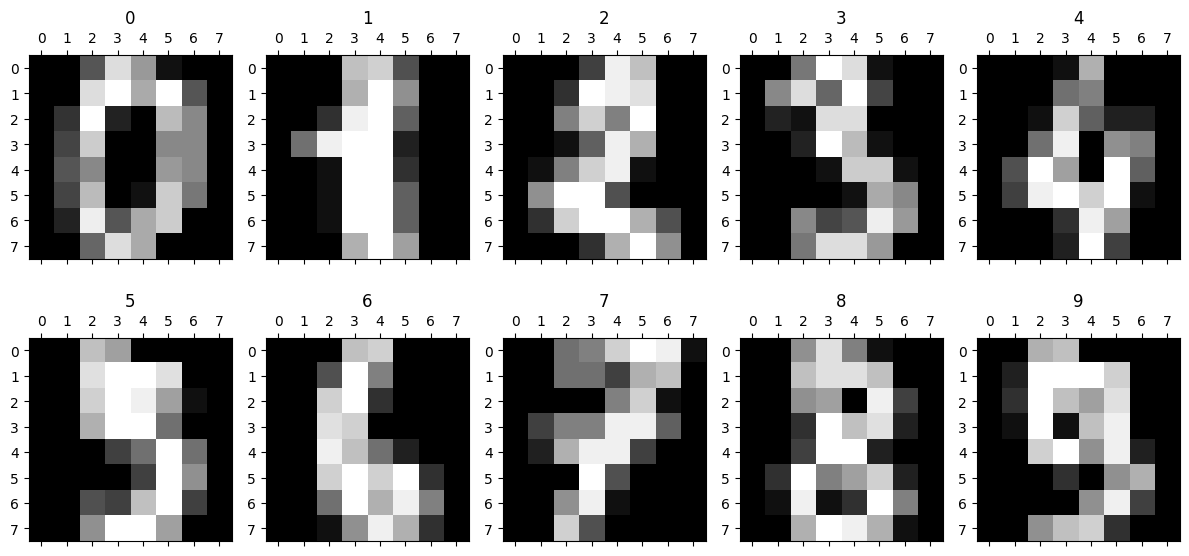

In [13]:
# Display images of the first 10 digits
fig, axs = plt.subplots(2, 5, sharey=False, tight_layout=True, figsize=(12,6), facecolor='white')
n=0
plt.gray()
for i in range(0,2):
    for j in range(0,5):
        axs[i,j].matshow(digits.images[n])
        axs[i,j].set(title=y[n])
        n=n+1
plt.show()

We will now apply Isomap to reduce the number of dimensions for each record in the X array from 64 to 3.

In [14]:
### Step 1 - Configure the Isomap function, note we use default hyperparameter values in this example
embed3 = Isomap(
    n_neighbors=5, # default=5, algorithm finds local structures based on the nearest neighbors
    n_components=3, # number of dimensions
)

### Step 2 - Fit the data and transform it, so we have 3 dimensions instead of 64
X_trans3 = embed3.fit_transform(X)

### Step 3 - Print shape to test
print('The new shape of X: ',X_trans3.shape)

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_isomap.py:384: UserWarning:

The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.

/usr/local/lib/python3.13/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning:

Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.



The new shape of X:  (1797, 3)


Finally, let’s plot a 3D scatter plot to see what the data looks like after reducing dimensions down to 3.

In [15]:
import plotly.io as pio
pio.renderers.default = "colab"
# Create a 3D scatter plot
fig = px.scatter_3d(None,
                    x=X_trans3[:,0], y=X_trans3[:,1], z=X_trans3[:,2],
                    color=y.astype(str),
                    height=900, width=900
                   )

# Update chart looks
fig.update_layout(#title_text="Scatter 3D Plot",
                  showlegend=True,
                  legend=dict(orientation="h", yanchor="top", y=0, xanchor="center", x=0.5),
                  scene_camera=dict(up=dict(x=0, y=0, z=1),
                                        center=dict(x=0, y=0, z=-0.2),
                                        eye=dict(x=-1.5, y=1.5, z=0.5)),
                                        margin=dict(l=0, r=0, b=0, t=0),
                  scene = dict(xaxis=dict(backgroundcolor='white',
                                          color='black',
                                          gridcolor='#f0f0f0',
                                          title_font=dict(size=10),
                                          tickfont=dict(size=10),
                                         ),
                               yaxis=dict(backgroundcolor='white',
                                          color='black',
                                          gridcolor='#f0f0f0',
                                          title_font=dict(size=10),
                                          tickfont=dict(size=10),
                                          ),
                               zaxis=dict(backgroundcolor='lightgrey',
                                          color='black',
                                          gridcolor='#f0f0f0',
                                          title_font=dict(size=10),
                                          tickfont=dict(size=10),
                                         )))

# Update marker size
fig.update_traces(marker=dict(size=2))

fig.show()